# Linear Regression from Scratch

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
data = pd.read_csv('data_for_lr.csv')

In [ ]:
data.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


In [ ]:
data.shape

(700, 2)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       700 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 11.1 KB


In [ ]:
data.isnull().sum()

,0
x,0
y,1


In [ ]:
data = data.dropna()
print("The new shape of the data is ", data.shape)

The new shape of the data is  (699, 2)


In [ ]:
#training input and output data
train_input = np.array(data.x[0:500]).reshape(500,1)
train_output = np.array(data.y[0:500]).reshape(500,1)

#validation or test data input and output data
test_input = np.array(data.x[500:700]).reshape(199,1)
test_output = np.array(data.y[500:699]).reshape(199,1)

In [ ]:
print(f"The shape of training input data = {train_input.shape}")
print(f"The shape of training output data = {train_output.shape}")
print(f"The shape of testing input data = {test_input.shape}")
print(f"The shape of testing output data = {test_output.shape}")

The shape of training input data = (500, 1)
The shape of training output data = (500, 1)
The shape of testing input data = (199, 1)
The shape of testing output data = (199, 1)


<font color = 'Green'><h1>**Linear Regression**</h1></font>

# **Forward Propagation**

In [ ]:
def forward_propagation(train_input, parameters):
  m = parameters["m"]
  c = parameters["c"]

  predictions = np.multiply(m, train_input) + c
  return predictions

# **Cost Function**

In [ ]:
#summation(1/2n * (y-f(x))^2)
def cost_function(predictions, train_output):
  cost = np.mean((train_output - predictions) ** 2) * 0.5
  return cost

# **Gradient Descent for Backpropagation**

df = summation(f(x)-y)/n

dm = df * x

dc = df*1

d(cost)/dm = df * df/dm

In [ ]:
def backward_propagation(train_input, train_output, predictions):
  derivatives = dict()
  df = predictions - train_output
  dm = np.mean(np.multiply(df, train_input))
  dc = np.mean(df)

  derivatives ['dm'] = dm
  derivatives ['dc'] = dc

  return derivatives

# **Update Parameters**
m' = m - (learning_rate * dm)

c' = c - (learning_rate * dc)

In [ ]:
def update_parameters(parameters, derivatives, learning_rate):
  parameters['m'] = parameters['m'] - learning_rate * derivatives['dm']
  parameters['c'] = parameters['c'] - learning_rate * derivatives['dc']

  return parameters

# **Train the Data**
Sequence of Steps:

*  Forward Propagtaion
*  Cost Function
*  Backward Propagation
*  Update Parameters

In [ ]:
def train(train_input, train_output, learning_rate, iters):

    #random parameters
    parameters = dict()
    parameters["m"] = np.random.uniform(0,1) * -1
    parameters["c"] = np.random.uniform(0,1) * -1

    plt.figure()

    #loss
    loss = list()

    #iterate
    for i in range(iters):

        #forward propagation
        predictions = forward_propagation(train_input, parameters)

        #cost function
        cost = cost_function(predictions, train_output)

        #append loss and print
        loss.append(cost)
        print("Iteration = {}, Loss = {}".format(i+1, cost))

        #plot function
        fig, ax = plt.subplots()

        ax.plot(train_input, train_output, '+', label='Original')
        ax.plot(train_input, predictions, '*', label='Training')

        legend = ax.legend()

        plt.plot(train_input, train_output, '+')
        plt.plot(train_input, predictions, '*')

        plt.show()

        #back propagation
        derivatives = backward_propagation(train_input, train_output, predictions)

        #update parameters
        parameters = update_parameters(parameters, derivatives, learning_rate)

    return parameters, loss

# **Training**

Iteration = 1, Loss = 3031.9677054325853


<Figure size 640x480 with 0 Axes>

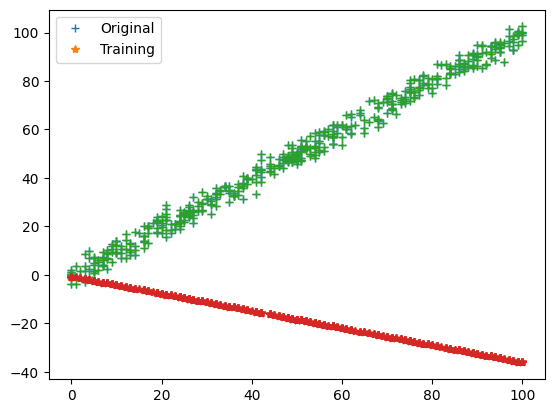

Iteration = 2, Loss = 1377.7558461933882


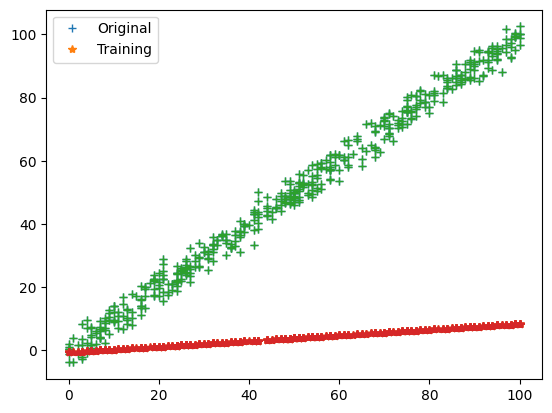

Iteration = 3, Loss = 627.23809275294


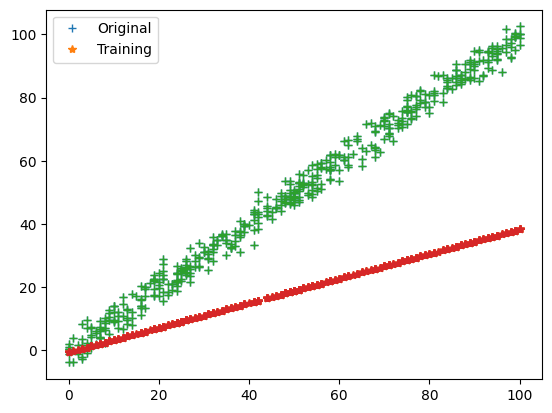

Iteration = 4, Loss = 286.7273560822528


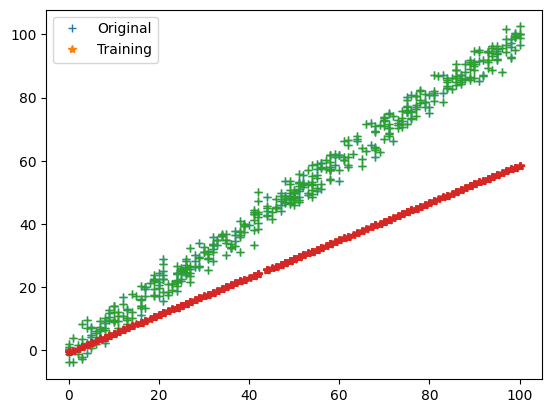

Iteration = 5, Loss = 132.23725706070775


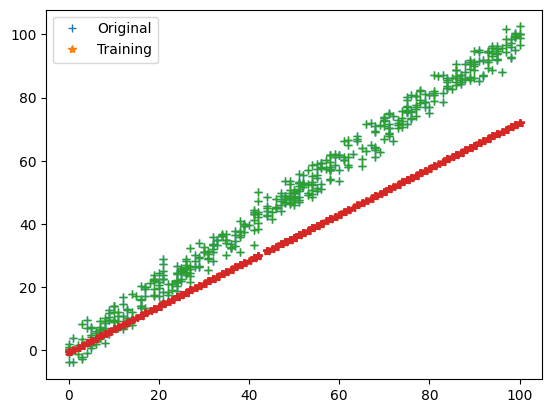

Iteration = 6, Loss = 62.14492738473521


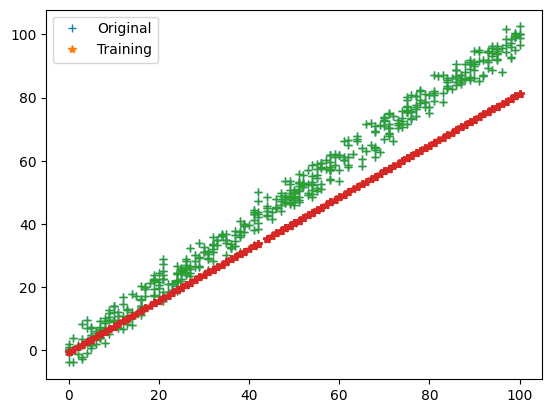

Iteration = 7, Loss = 30.34395914332846


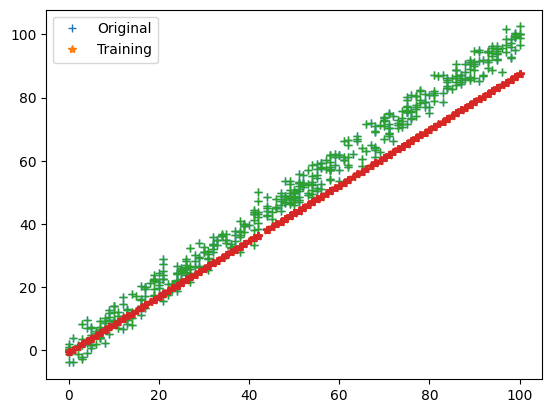

Iteration = 8, Loss = 15.9158239979059


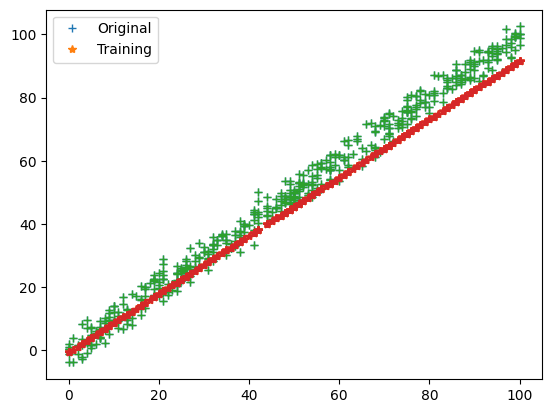

Iteration = 9, Loss = 9.369762471029135


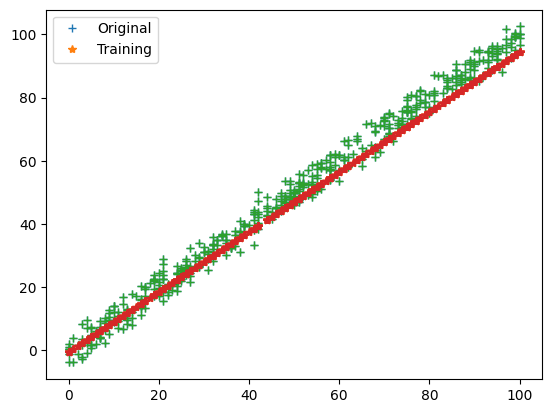

Iteration = 10, Loss = 6.39980647542792


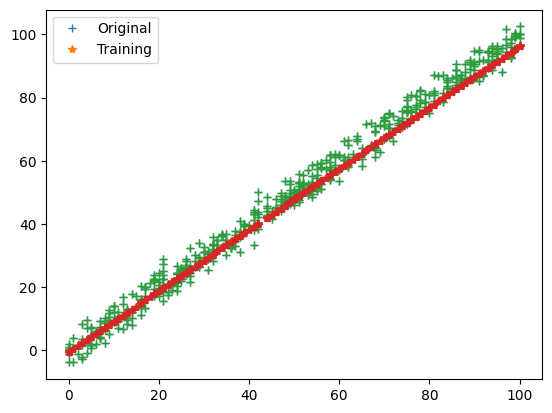

Iteration = 11, Loss = 5.052333520440026


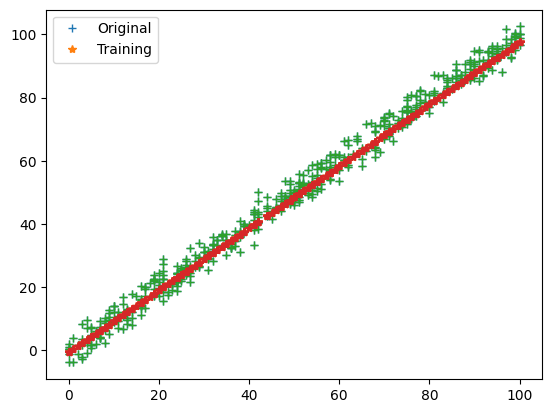

Iteration = 12, Loss = 4.440982918139244


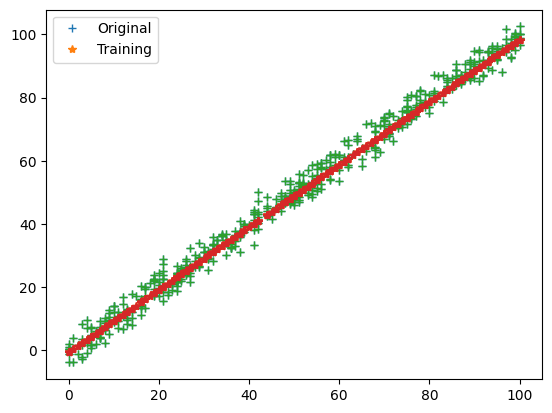

Iteration = 13, Loss = 4.163611842643778


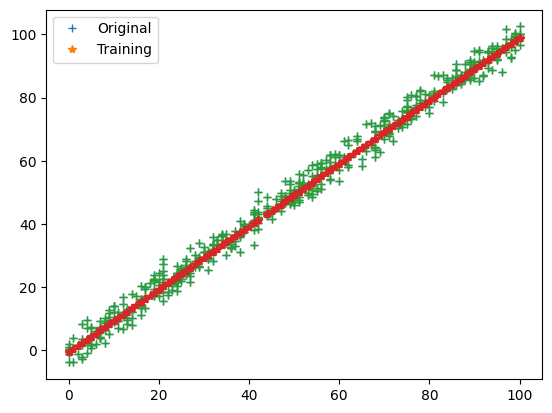

Iteration = 14, Loss = 4.0377676484211245


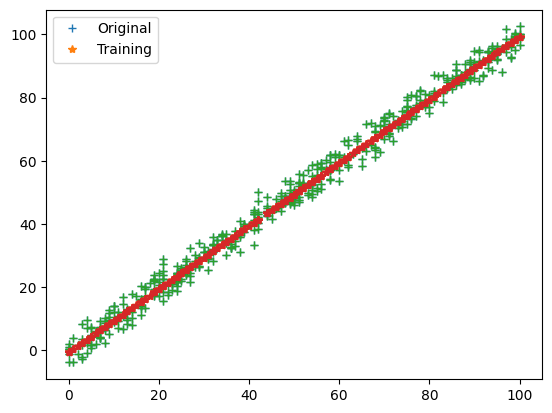

Iteration = 15, Loss = 3.980671368101101


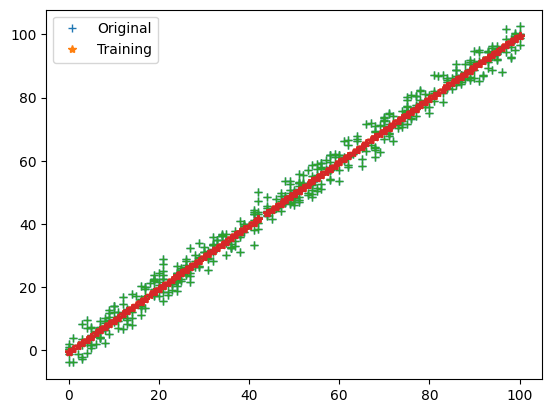

Iteration = 16, Loss = 3.9547660924984567


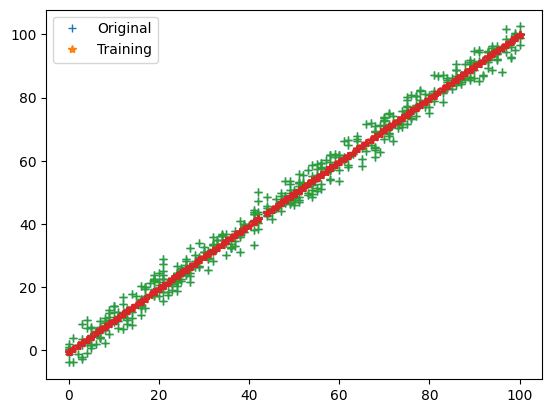

Iteration = 17, Loss = 3.943012210316265


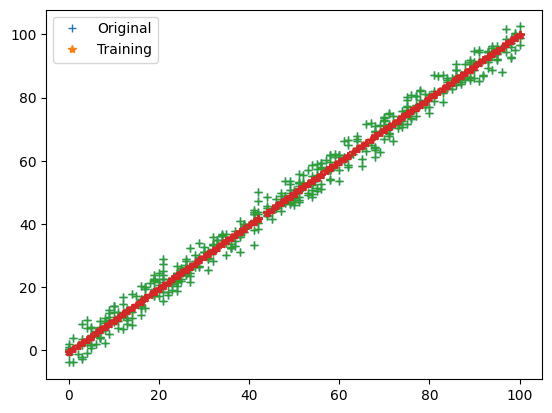

Iteration = 18, Loss = 3.9376788310353303


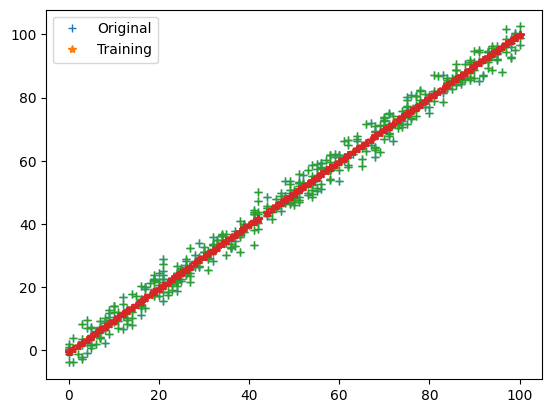

Iteration = 19, Loss = 3.9352584410640423


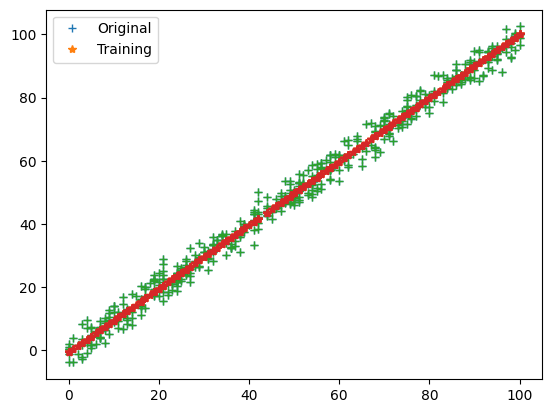

Iteration = 20, Loss = 3.9341596776008174


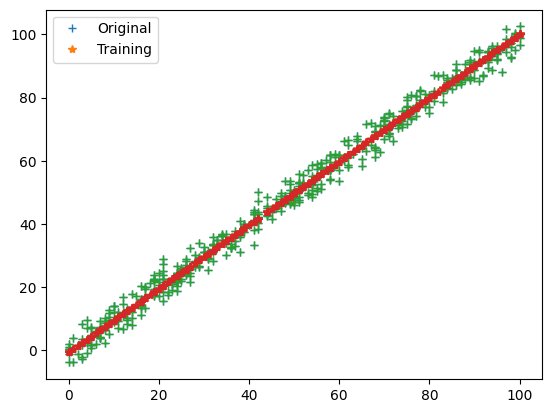

In [ ]:
parameters, loss = train(train_input, train_output, 0.0001, 20)

In [ ]:
print(parameters)

{'m': np.float64(1.0042330930898489), 'c': np.float64(-0.4815909737516504)}


# **Let's Predict**

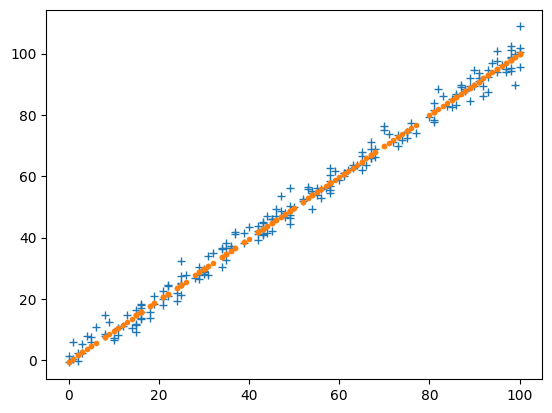

In [ ]:
test_predictions = test_input * parameters["m"] + parameters["c"]
plt.figure()
plt.plot(test_input, test_output, '+')
plt.plot(test_input, test_predictions, '.')
plt.show()

In [ ]:
cost_function(test_predictions, test_output)

np.float64(4.058810749699784)